In [2]:
from boututils.datafile import DataFile
from boutdata.collect import collect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os, sys, pathlib
import platform
import traceback
import xarray as xr
import xbout
from pathlib import Path
import xhermes as xh

sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/sdtools"))
# sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/my_notebooks/notebooks/hermes-3/transients"))
sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/notebooks/hermes-3/general_functions"))


from plotting_functions import *
from convergence_functions import * 

from hermes3.case_db import *
from hermes3.casedeck import*
from hermes3.load import *
from hermes3.named_selections import *
from hermes3.plotting import *
from hermes3.grid_fields import *
from hermes3.accessors import *
from hermes3.utils import *
from hermes3.fluxes import *
from hermes3.selectors import *
from hermes3.front_tracking import *
from hermes3.neutral_transport import *

# from code_comparison.code_comparison import *
from code_comparison.solps_pp import *
from code_comparison.solps_variables import *
# from code_comparison.viewer_2d import *

# from hermes3.balance1d import *

# plt.style.use('ggplot')
plt.rcParams.update({'font.size': 10})
linewidth = 3
markersize = 15



# plt.style.use('ggplot')
mpl.style.use('default')
mpl.rcParams["axes.edgecolor"] = "black"
mpl.rcParams["axes.linewidth"] = 1
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['axes.grid'] = True
mpl.rcParams.update({'font.size': 16})



%load_ext autoreload
%autoreload 2


In [3]:
case = SOLPScase('/Users/lloyd/Documents/hermes_dir/york-step_analysis_intro/data/solps')


In [4]:

fline = case.get_1d_poloidal_data(
    params = ['Bpol', 'Btor', 'R'],
    region = 'outer_lower',
    sepadd = 0,
    target_first = False,
    guards = False
)

print(fline['Spar'].values[-1])

27.520701887675383


# Simple 1D grid

In [5]:
import numpy as np
from netCDF4 import Dataset

# Grid parameters
nx = 1
ny = 400
nz = 1

# Physical parameters
length = 30.0
length_xpt = 10.0
dymin = 0.1

# BOUT++ coordinate
y_bout = np.linspace(0, 2*np.pi, ny, endpoint=False)

# Non-uniform dy array
dy_array = (length / ny) * (1 + (1 - dymin) * (1 - y_bout / np.pi))

# Calculate parallel distance (lpar)
lpar_1d = np.zeros(ny)
lpar_1d[0] = 0.5 * dy_array[0]
for i in range(1, ny):
    lpar_1d[i] = lpar_1d[i-1] + 0.5 * (dy_array[i-1] + dy_array[i])

print(f"1D grid lpar range: [{lpar_1d[0]:.3f}, {lpar_1d[-1]:.3f}] m")

# Calculate X-point location
source = length_xpt / length
y_xpt = np.pi * (2 - dymin - np.sqrt((2 - dymin)**2 - 4*(1 - dymin)*source)) / (1 - dymin)

print(f"X-point at y = {y_xpt:.6f} rad")

# Create netCDF file
output_file = 'grid_1d_minimal.nc'
with Dataset(output_file, 'w', format='NETCDF3_CLASSIC') as ncfile:
    
    # Create dimensions
    x_dim = ncfile.createDimension('x', nx)
    y_dim = ncfile.createDimension('y', ny)
    z_dim = ncfile.createDimension('z', nz)
    
    # Dimension sizes
    nx_var = ncfile.createVariable('nx', 'i4')
    ny_var = ncfile.createVariable('ny', 'i4')
    nz_var = ncfile.createVariable('nz', 'i4')
    nx_var[:] = nx
    ny_var[:] = ny
    nz_var[:] = nz
    
    # Cell spacings
    dx_var = ncfile.createVariable('dx', 'f8', ('x', 'y'))
    dx_var[:, :] = 0.01
    
    dy_var = ncfile.createVariable('dy', 'f8', ('x', 'y'))
    dy_var[0, :] = dy_array
    
    dz_var = ncfile.createVariable('dz', 'f8')
    dz_var[:] = 2.0 * np.pi / nz
    
    # Jacobian
    J_var = ncfile.createVariable('J', 'f8', ('x', 'y'))
    J_var[:, :] = 1.0
    
    # Separatrix indices
    ixseps1_var = ncfile.createVariable('ixseps1', 'i4')
    ixseps1_var[:] = -1
    ixseps2_var = ncfile.createVariable('ixseps2', 'i4')
    ixseps2_var[:] = -1

    # Store custom parameters as scalar variables
    # Physical domain parameters
    length_var = ncfile.createVariable('length', 'f8')
    length_var[:] = length
    length_var.units = 'm'
    length_var.long_name = 'Total length of domain'
    
    length_xpt_var = ncfile.createVariable('length_xpt', 'f8')
    length_xpt_var[:] = length_xpt
    length_xpt_var.units = 'm'
    length_xpt_var.long_name = 'Length from midplane to X-point'
    
    dymin_var = ncfile.createVariable('dymin', 'f8')
    dymin_var[:] = dymin
    dymin_var.long_name = 'Minimum grid spacing fraction'
    
    # X-point location in coordinate space
    y_xpt_var = ncfile.createVariable('y_xpt', 'f8')
    y_xpt_var[:] = y_xpt
    y_xpt_var.units = 'radians'
    y_xpt_var.long_name = 'Y-coordinate of X-point'
    
    # Source parameter (for reference)
    source_var = ncfile.createVariable('source', 'f8')
    source_var[:] = source
    source_var.long_name = 'Normalized source length'
    
    # Metadata
    ncfile.description = '1D BOUT++ grid with all parameters included'

print(f"\nCreated grid file: {output_file}")
print(f"Grid parameters stored:")
print(f"  length = {length} m")
print(f"  length_xpt = {length_xpt} m")
print(f"  dymin = {dymin}")
print(f"  y_xpt = {y_xpt:.6f} rad")

1D grid lpar range: [0.071, 30.064] m
X-point at y = 1.213292 rad

Created grid file: grid_1d_minimal.nc
Grid parameters stored:
  length = 30.0 m
  length_xpt = 10.0 m
  dymin = 0.1
  y_xpt = 1.213292 rad


# Averaging over SOL Rings

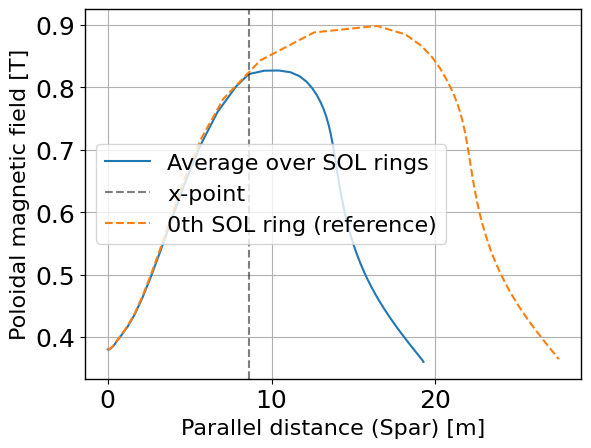

In [6]:
def average_flux_tubes(case, sepadd=0, sepdist=None, region='outer_lower'):
    """
    Averages SOLPS geometry profiles over SOL rings.

    Arguments:
        case: The case object providing get_1d_poloidal_data().
        sepadd: Number/index/list/range of SOL rings to average, or 0 for reference ring. 
        sepdist: If given (float), average over all SOL rings within this (radial) distance from the separatrix.
        region: SOL ring region ('outer_lower', etc.)
    Returns:
        data: dict with averaged profiles. The coordinate is 'Spar', averaged over flux tubes.
    """
    params = ["R", "Z", "Bpol", "Btor"]
    data = {}

    # Use sepdist if provided
    if sepdist is not None:
        # get_1d_poloidal_data with sepdist retrieves all sol rings within that distance
        # sepadd is ignored in this case
        # We expect get_1d_poloidal_data to return a list/iterable of fline objects (no return_list kwarg)
        fline_list = case.get_1d_poloidal_data(
            params=params,
            region=region,
            sepdist=sepdist,
            target_first=False,
            guards=False
        )
        # If it returns a single fline (dict/obj), wrap in a list
        if not isinstance(fline_list, (list, tuple)):
            fline_list = [fline_list]

        tmp_data = {p: [] for p in params}
        spar_collect = []

        for fline in fline_list:
            spar_collect.append(fline['Spar'].values)
            for p in params:
                tmp_data[p].append(fline[p].values)

        spar_array = np.asarray(spar_collect)
        if spar_array.ndim == 2:
            if np.all(np.ptp(spar_array, axis=0) < 1e-10):  # all flux tubes align
                spar_mean = spar_array[0]
            else:
                spar_mean = np.mean(spar_array, axis=0)
        else:
            spar_mean = spar_array

        for p in params:
            data[p] = np.mean(np.asarray(tmp_data[p]), axis=0)
        data['Spar'] = spar_mean
        return data

    # If sepadd is 0 (or evaluates to False), just return the 0th SOL ring (no averaging)
    if sepadd == 0:
        fline = case.get_1d_poloidal_data(
            params=params,
            region=region,
            sepadd=0,
            target_first=False,
            guards=False
        )
        for p in params:
            data[p] = fline[p].values
        data['Spar'] = fline['Spar'].values
        return data

    # Otherwise, average over sepadd rings (assume sepadd is int > 0, or list/tuple/range)
    if isinstance(sepadd, int):
        indices = range(sepadd)
    else:
        indices = sepadd

    tmp_data = {p: [] for p in params}
    spar_collect = []

    for i in indices:
        fline = case.get_1d_poloidal_data(
            params=params,
            region=region,
            sepadd=i,
            target_first=False,
            guards=False
        )
        spar_collect.append(fline['Spar'].values)
        for p in params:
            tmp_data[p].append(fline[p].values)

    # Convert lists to numpy arrays
    spar_array = np.asarray(spar_collect)
    # Check shape: expect (num_tubes, Npoints)
    if spar_array.ndim == 2:
        if np.all(np.ptp(spar_array, axis=0) < 1e-10):  # checks if all flux tubes align
            spar_mean = spar_array[0]
        else:
            spar_mean = np.mean(spar_array, axis=0)
    else:
        spar_mean = spar_array

    # Average over flux tubes axis (0)
    for p in params:
        data[p] = np.mean(np.asarray(tmp_data[p]), axis=0)
    # Add coordinate back so user can plot
    data['Spar'] = spar_mean

    return data

fig, ax = plt.subplots()
test = average_flux_tubes(case, sepadd=6)

# Get reference from 0th SOL ring
ref = case.get_1d_poloidal_data(
    params=["R", "Z", "Bpol", "Btor"],
    region='outer_lower',
    sepadd=0,
    target_first=False,
    guards=False
)
ref_spar = ref['Spar'].values
ref_btor = ref['Btor'].values

ax.plot(test['Spar'], test['Btor'], label='Average over SOL rings')
xpoint_index = np.argmin(test['Bpol'])
ax.axvline(test['Spar'][xpoint_index], color='k', linestyle='--', alpha=0.5, label='x-point')
ax.plot(ref_spar, ref_btor, '--', label='0th SOL ring (reference)')

ax.set_xlabel('Parallel distance (Spar) [m]')
ax.set_ylabel('Poloidal magnetic field [T]')
ax.legend()
plt.show()

# Grid with SOLPS data

Using single flux tube: sepadd=0
Initial 1D grid lpar range: [0.065362, 27.579029] m
SOLPS lpar range: [0.000000, 27.520702] m
Rescaled 1D grid lpar range: [0.000000, 27.520702] m
Difference at endpoint: 0.000000000 m
Number of 1D points beyond SOLPS range: 0


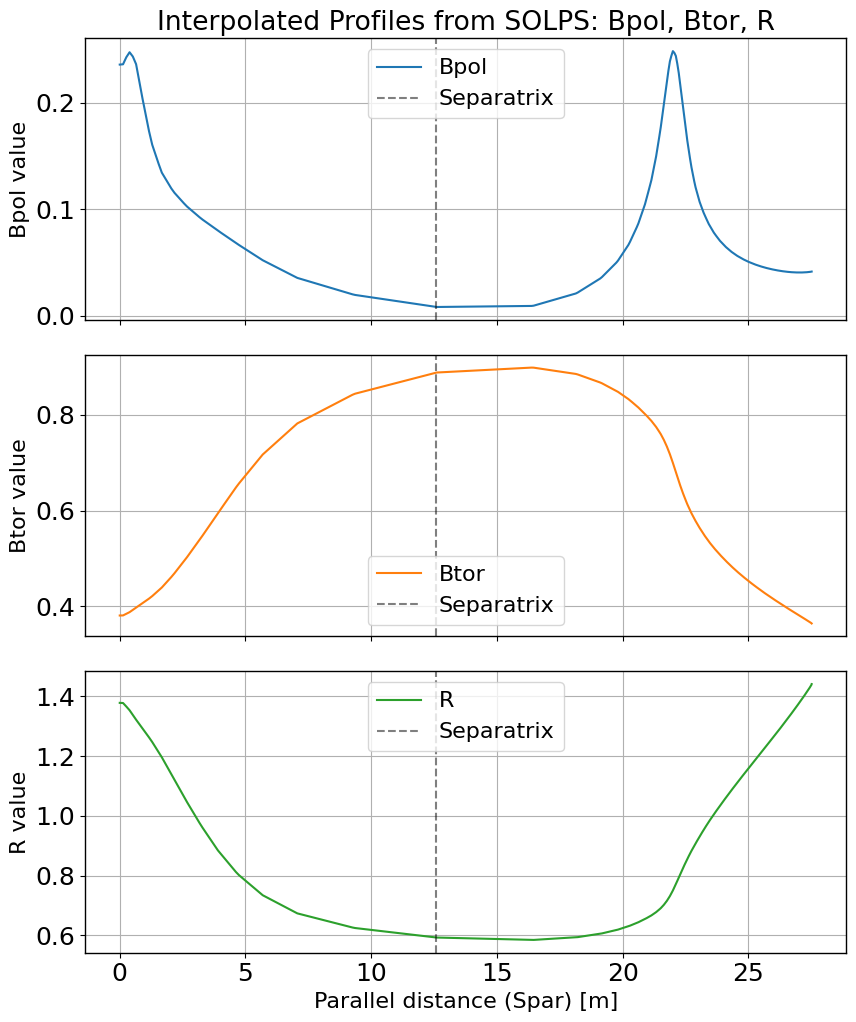


Interpolated data ranges:
  Bpol: [0.008, 0.248]
  Btor: [0.364, 0.898]
  R: [0.585, 1.441]

Created grid file: sol_ring_0.nc
Ready to use in Hermes-3 (lambda_int set in input file)


'sol_ring_0.nc'

In [13]:
import numpy as np
from netCDF4 import Dataset
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

def grid_poloidal_profiles(
    case,
    nx=1,
    ny=400,
    nz=1,
    dymin=0.1,
    sepadd=0,  # Can now be int, list, tuple, or range
    region='outer_lower',
    params=['Bpol', 'Btor', 'R'],
    output_file='grid_1d_from_2d.nc',
    plot_profiles=True
):
    """
    Generate a BOUT++ 1D grid file with magnetic/geometry data interpolated from SOLPS case

    Parameters
    ----------
    case : A SOLPS or Hermes3 case object with get_1d_poloidal_data method.
    nx, ny, nz : int
        3D grid dimensions (default 1, 400, 1).
    dymin : float
        Minimum grid spacing fraction (default 0.1).
    sepadd : int, list, tuple, or range
        Single flux tube index or collection of indices to average over (default 0).
        Examples: sepadd=0, sepadd=[0,1,2], sepadd=range(0,5)
    region : str
        Region for poloidal data (default 'outer_lower').
    params : list of str
        List of SOLPS parameters to interpolate and save (default ['Bpol', 'Btor', 'R']).
    output_file : str
        Filename to write grid NetCDF to.
    plot_profiles : bool
        If True, plot each interpolated profile on its own subplot against Spar.
    """
    # Determine if we're averaging over multiple flux tubes
    if isinstance(sepadd, (list, tuple, range)):
        sepadd_values = list(sepadd)
        print(f"Averaging over {len(sepadd_values)} flux tubes: sepadd={sepadd_values}")
    else:
        sepadd_values = [sepadd]
        print(f"Using single flux tube: sepadd={sepadd}")
    
    # Collect data from all specified flux tubes
    profile_data_2d = {key: [] for key in params}
    lpar_2d = None
    xpoint_indices = []
    
    for sep in sepadd_values:
        fline = case.get_1d_poloidal_data(
            params=list(params),
            region=region,
            sepadd=sep,
            target_first=False,
            guards=False
        )
        
        # Store Spar from first iteration (assuming all have same coordinate)
        if lpar_2d is None:
            lpar_2d = fline['Spar'].values
        
        # Collect profile data for averaging
        for key in params:
            profile_data_2d[key].append(fline[key].values)
        
        # Track x-point location for each flux tube
        xpoint_indices.append(np.argmin(fline['Bpol']))
    
    # Average the profiles across all flux tubes
    for key in params:
        profile_data_2d[key] = np.mean(profile_data_2d[key], axis=0)
    
    # Use average x-point index
    xpoint_index = int(np.mean(xpoint_indices))

    # Set length parameters
    length = lpar_2d[-1]
    length_xpt = lpar_2d[xpoint_index]
    
    # BOUT++ grid in y: [0, 2pi)
    y_bout = np.linspace(0, 2*np.pi, ny, endpoint=False)

    # Non-uniform dy definition
    dy_array = (length / ny) * (1 + (1 - dymin) * (1 - y_bout / np.pi))

    # Integrate dy to get the 1D grid's lpar
    lpar_1d = np.zeros(ny)
    lpar_1d[0] = 0.5 * dy_array[0]
    for i in range(1, ny):
        lpar_1d[i] = lpar_1d[i-1] + 0.5 * (dy_array[i-1] + dy_array[i])
        
    print(f"Initial 1D grid lpar range: [{lpar_1d[0]:.6f}, {lpar_1d[-1]:.6f}] m")
    print(f"SOLPS lpar range: [{lpar_2d[0]:.6f}, {lpar_2d[-1]:.6f}] m")

    # Rescale lpar_1d to the exact SOLPS range
    lpar_solps_min = lpar_2d[0]
    lpar_solps_max = lpar_2d[-1]
    lpar_1d = lpar_solps_min + (lpar_1d - lpar_1d[0]) * (lpar_solps_max - lpar_solps_min) / (lpar_1d[-1] - lpar_1d[0])

    print(f"Rescaled 1D grid lpar range: [{lpar_1d[0]:.6f}, {lpar_1d[-1]:.6f}] m")
    print(f"Difference at endpoint: {lpar_1d[-1] - lpar_solps_max:.9f} m")
    print(f"Number of 1D points beyond SOLPS range: {np.sum(lpar_1d > lpar_solps_max)}")

    # Use actual length for this grid
    length = lpar_solps_max
    
    # Calculate X-point location in y
    source = length_xpt / length
    y_xpt = np.pi * (2 - dymin - np.sqrt((2 - dymin)**2 - 4*(1 - dymin)*source)) / (1 - dymin)

    # Interpolate 2D SOLPS parameters to 1D BOUT++ grid coordinates
    profile_data_1d = {}
    for key in params:
        interp_func = interp1d(lpar_2d, profile_data_2d[key], kind='linear', bounds_error=False, fill_value='extrapolate')
        profile_data_1d[key] = interp_func(lpar_1d)

    # Plot each interpolated profile on its own subplot if requested
    if plot_profiles:
        nparams = len(params)
        fig, axes = plt.subplots(nparams, 1, figsize=(9, 3.5 * nparams), sharex=True)
        title_str = f"Interpolated Profiles from SOLPS: {', '.join(params)}"
        if len(sepadd_values) > 1:
            title_str += f"\n(Averaged over {len(sepadd_values)} flux tubes)"
        axes[0].set_title(title_str)
        if nparams == 1:
            axes = [axes]
        prop_cycle = plt.rcParams['axes.prop_cycle']
        colors = prop_cycle.by_key()['color']
        for idx, key in enumerate(params):
            color = colors[idx % len(colors)]
            ax = axes[idx]
            ax.plot(lpar_1d, profile_data_1d[key], label=key, color=color)
            ax.axvline(length_xpt, color='k', linestyle='--', alpha=0.5, label='Separatrix')
            ax.set_ylabel(f'{key} value')
            ax.grid(True)
            ax.legend()
        axes[-1].set_xlabel('Parallel distance (Spar) [m]')
        plt.tight_layout()
        plt.show()
    
    # Show interpolated ranges
    print("\nInterpolated data ranges:")
    for key in params:
        print(f"  {key}: [{np.min(profile_data_1d[key]):.3f}, {np.max(profile_data_1d[key]):.3f}]")
    
    # Write NetCDF grid file
    with Dataset(output_file, 'w', format='NETCDF3_CLASSIC') as ncfile:
        # Create dimensions and size variables
        ncfile.createDimension('x', nx)
        ncfile.createDimension('y', ny)
        ncfile.createDimension('z', nz)

        nx_var = ncfile.createVariable('nx', 'i4')
        ny_var = ncfile.createVariable('ny', 'i4')
        nz_var = ncfile.createVariable('nz', 'i4')
        nx_var[:] = nx
        ny_var[:] = ny
        nz_var[:] = nz

        # Uniform/cell spacing
        dx_var = ncfile.createVariable('dx', 'f8', ('x', 'y'))
        dx_var[:, :] = 0.01

        dy_var = ncfile.createVariable('dy', 'f8', ('x', 'y'))
        dy_var[0, :] = dy_array

        dz_var = ncfile.createVariable('dz', 'f8')
        dz_var[:] = 2.0 * np.pi / nz

        # Jacobian
        J_var = ncfile.createVariable('J', 'f8', ('x', 'y'))
        J_var[:, :] = 1.0

        # Separatrix indices
        ixseps1_var = ncfile.createVariable('ixseps1', 'i4')
        ixseps1_var[:] = -1
        ixseps2_var = ncfile.createVariable('ixseps2', 'i4')
        ixseps2_var[:] = -1

        # X-point location
        y_xpt_var = ncfile.createVariable('y_xpt', 'f8')
        y_xpt_var[:] = y_xpt

        # Save interpolated profiles as 3D arrays (x, y, z)
        for key in params:
            arr3d = profile_data_1d[key].reshape(1, ny, 1)
            units = None
            long_name = None
            # Make some standard units/long names for key
            if key.lower() in ['bpol']:
                units = 'T'
                long_name = 'Poloidal magnetic field from 2D simulation'
            elif key.lower() in ['btor']:
                units = 'T'
                long_name = 'Toroidal magnetic field from 2D simulation'
            elif key.lower() in ['r']:
                units = 'm'
                long_name = 'Major radius from 2D simulation'
            else:
                units = ''
                long_name = f'{key} profile from SOLPS'
            
            # Add averaging info to long_name if applicable
            if len(sepadd_values) > 1:
                long_name += f' (averaged over {len(sepadd_values)} flux tubes)'
            
            var = ncfile.createVariable(key, 'f8', ('x', 'y', 'z'))
            var[:, :, :] = arr3d
            var.units = units
            var.long_name = long_name

        # Also store the lpar coordinate vector for reference
        lpar_var = ncfile.createVariable('lpar', 'f8', ('y',))
        lpar_var[:] = lpar_1d
        lpar_var.units = 'm'
        lpar_var.long_name = 'Parallel distance along field line'

        # Metadata
        ncfile.description = '1D grid with interpolated data from 2D simulation'
        ncfile.source_2d = 'SOLPS-ITER data'
        if len(sepadd_values) > 1:
            ncfile.sepadd_averaged = f'Averaged over flux tubes: {sepadd_values}'
        else:
            ncfile.sepadd = sepadd_values[0]

    print(f"\nCreated grid file: {output_file}")
    print("Ready to use in Hermes-3 (lambda_int set in input file)")
    return output_file

# Example usage:
# Single flux tube (original behavior):
grid_poloidal_profiles(case, sepadd=0, output_file = 'sol_ring_0.nc')

# Average over multiple flux tubes:
# grid_poloidal_profiles(case, sepadd=[0, 1, 2])
# grid_poloidal_profiles(case, sepadd=range(0, 5))

# hermes-3 test

In [8]:
ds = xh.open('/Users/lloyd/Documents/hermes_dir/hermes-3/build-minmod-geometry_1d_grid/examples/tokamak-1D/1D-grid-test_2D')

ds = ds.hermes.extract_1d_tokamak_geometry()



In [9]:
print(ds.data_vars)

Data variables:
    Bxy                                         (pos) float64 3kB dask.array<chunksize=(400,), meta=np.ndarray>
    Ed+_iz                                      (t, pos) float64 35kB dask.array<chunksize=(1, 400), meta=np.ndarray>
    Ed+_rec                                     (t, pos) float64 35kB dask.array<chunksize=(1, 400), meta=np.ndarray>
    Ed_target_recycle                           (t, pos) float64 35kB dask.array<chunksize=(1, 400), meta=np.ndarray>
    Edd+_cx                                     (t, pos) float64 35kB dask.array<chunksize=(1, 400), meta=np.ndarray>
    Fd+_iz                                      (t, pos) float64 35kB dask.array<chunksize=(1, 400), meta=np.ndarray>
    Fd+_rec                                     (t, pos) float64 35kB dask.array<chunksize=(1, 400), meta=np.ndarray>
    Fdd+_cx                                     (t, pos) float64 35kB dask.array<chunksize=(1, 400), meta=np.ndarray>
    G1                                        

<xarray.DataArray 'fieldline_geometry_flux_tube_width' (pos: 400)> Size: 3kB
dask.array<getitem, shape=(400,), dtype=float64, chunksize=(400,), chunktype=numpy.ndarray>
Coordinates:
  * pos      (pos) float64 3kB -0.1957 -0.06513 0.06513 ... 27.3 27.31 27.32
    dx       (pos) float64 3kB dask.array<chunksize=(400,), meta=np.ndarray>
    dy       (pos) float64 3kB dask.array<chunksize=(400,), meta=np.ndarray>
    dz       (pos) float64 3kB dask.array<chunksize=(400,), meta=np.ndarray>
    x        int64 8B 0
    y        (pos) float64 3kB 0.06536 0.1959 0.3262 ... 27.56 27.57 27.58
    z        float64 8B 3.142
Attributes:
    cell_location:  CELL_CENTRE
    conversion:     0.0010217477552952484
    direction_y:    Standard
    direction_z:    Standard
    long_name:      Local flux tube radial width (lambda_q + 1.64S) * flux_ex...
    source:         fieldline_geometry
    units:          m
    metadata:       {'BOUT_VERSION': 5.2, 'Bnorm': 1.0, 'Cs0': 97871.51425755...
    options:  

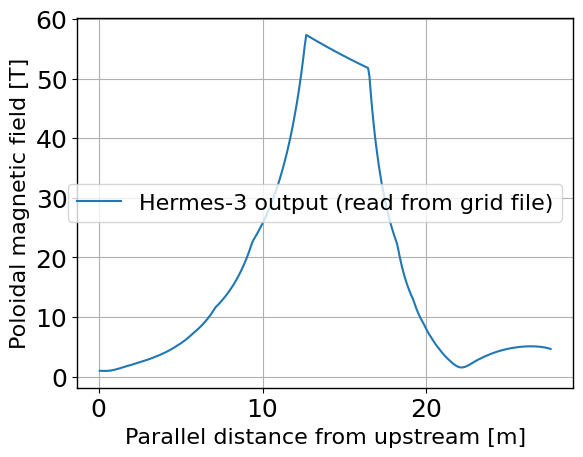

In [10]:
fig, ax = plt.subplots()

print(ds['fieldline_geometry_flux_tube_width'])

fline = case.get_1d_poloidal_data(
    params = ['Bpol', 'Btor', 'R', 'Te'],
    region = 'outer_lower',
    sepadd = 0,
    target_first = False,
    guards = False
)

# y = ds['y']
# ny = ds.dims['y']

ax.plot(ds['fieldline_geometry_lpar'], ds['fieldline_geometry_flux_expansion'], label = 'Hermes-3 output (read from grid file)')
# ax.scatter(ny[2:-3], ds['fieldline_geometry_cell_side_area'][0][2:-3], label = 'Hermes-3 output (read from grid file)')

# ax.plot(fline['Spar'], fline['Bpol'], label = 'SOLPS data')
ax.set_xlabel(f'{ds['fieldline_geometry_lpar'].attrs['long_name']} [{ds['fieldline_geometry_lpar'].units}]')
ax.set_ylabel('Poloidal magnetic field [T]')
ax.legend()
plt.show()


In [11]:
print(fline['Spar'])

0      0.000000
1      0.124966
2      0.367642
3      0.617279
4      0.900166
        ...    
62    27.424838
63    27.470012
64    27.502039
65    27.520517
66    27.520702
Name: Spar, Length: 67, dtype: float64
